<a href="https://colab.research.google.com/github/JSEFERINO/DISE-O2025/blob/main/202509_DOE_TRES_FACTORES_PARTE2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a name="inicio"></a>


## **1.** [El Problema](#T1)
## **2.** [Datos del problema](#T2)

## **3.**  [Modelo del Problema](#T3)

## **4.** [Hipótesis del Problema](#T4)

## **5.** [El DataFrame](#T5)

## **6.** [Análisis de Varianza (ANOVA)](#T6)

## **7.** [  Interpretación de los Resultados del ANOVA](#T7)


## **8.** [Prueba HSD comparaciones Múltiples - NO cincide con el Anova](#T8)

## **9.** [Librerias para Trabajar en R](#T9)


## **10.** [El Problema en R - dataframe](#T10)

## **11.** [El Anova en R](#T11)

## **12.** [Prueba HSD comparaciones Múltiples - Coincide con el Anova](#T12)

## **13.** [Prediciendo el mejor tratamiento](#T13)

## **14.** [Gráfico de Interacciones](#T14)

## **15.** [](#T15)

## **16.** [](#T16)

## **17.** [](#T17)

## **18.** [](#T18)

## **19.** [](#T19)

[⬆️ Volver al inicio](#inicio)

<a name="T1"></a>
## **1. El Problema**
# **Diseño Factorial ($3 \times 2 \times 2$)**
+ (tres niveles de Temperatura **A**, dos niveles de Presión **B** y dos niveles de Tiempo **C**) con 3 réplicas en cada combinación.
---

## 📘 **Enunciado del Problema**

**Problema 1:**
Se tiene interés en el rendimiento de un proceso; en particular para ello se consideran tres factores:

* **A:** Efecto de la **Temperatura** (100, 120, 140 °C).
* **B:** La **Presión** (400, 450).
* **C:** El **Tiempo** del lavado del producto en seguida del proceso de enfriamiento (30 y 35 minutos).

Se realizan tres pruebas en cada combinación de los factores. Los resultados del experimento son los siguientes:


[⬆️ Volver al inicio](#inicio)

<a name="T2"></a>
## **2. DataFrame en Python**


---

## 📊 DataFrame en Python

```python
import pandas as pd

# Datos organizados
data = {
    "Temperatura": [100]*12 + [120]*12 + [140]*12,
    "Presion": ([400]*6 + [450]*6)*3,
    "Tiempo": ([30]*3 + [35]*3)*4,
    "Replica": [1,2,3]*8,
    "Rendimiento": [
        34,32,33, 27,29,28,   # A=100, B=400, C=30 y 35
        33,33,33, 29,28,27,   # A=100, B=450, C=30 y 35

        32,34,34, 26,28,27,   # A=120, B=400, C=30 y 35
        32,32,32, 30,29,28,   # A=120, B=450, C=30 y 35

        36,34,37, 29,27,29,   # A=140, B=400, C=30 y 35
        34,32,34, 28,28,29    # A=140, B=450, C=30 y 35
    ]
}

df = pd.DataFrame(data)
print(df)
```

---

¿Quieres que te prepare también la **tabla completa del DataFrame en Markdown** para visualizarla directamente aquí, o prefieres solo el código en Python?


[⬆️ Volver al inicio](#inicio)

<a name="T3"></a>
## **3. Modelo del Problema**


El modelo lineal general para un diseño factorial $3 \times 2 \times 2$ con 3 réplicas puede escribirse como:

$Y_{ijkl} = \mu + \alpha_i + \beta_j + \gamma_k + (\alpha\beta)_{ij} + (\alpha\gamma)_{ik} + (\beta\gamma)_{jk} + (\alpha\beta\gamma)_{ijk} + \epsilon_{ijkl}$

Donde:

*   $Y_{ijkl}$ es la observación del rendimiento en la $i$-ésima temperatura, $j$-ésima presión, $k$-ésimo tiempo y $l$-ésima réplica.
*   $\mu$ es la media general del rendimiento.
*   $\alpha_i$ es el efecto del $i$-ésimo nivel de temperatura ($i = 1, 2, 3$).
*   $\beta_j$ es el efecto del $j$-ésimo nivel de presión ($j = 1, 2$).
*   $\gamma_k$ es el efecto del $k$-ésimo nivel de tiempo ($k = 1, 2$).
*   $(\alpha\beta)_{ij}$ es el efecto de interacción entre la $i$-ésima temperatura y la $j$-ésima presión.
*   $(\alpha\gamma)_{ik}$ es el efecto de interacción entre la $i$-ésima temperatura y el $k$-ésimo tiempo.
*   $(\beta\gamma)_{jk}$ es el efecto de interacción entre la $j$-ésima presión y el $k$-ésimo tiempo.
*   $(\alpha\beta\gamma)_{ijk}$ es el efecto de interacción de tercer orden entre la $i$-ésima temperatura, la $j$-ésima presión y el $k$-ésimo tiempo.
*   $\epsilon_{ijkl}$ es el error aleatorio asociado a la observación $Y_{ijkl}$, asumiendo que $\epsilon_{ijkl} \sim N(0, \sigma^2)$ y son independientes.

Las restricciones habituales para este modelo (bajo el enfoque de efectos fijos) son:

$\sum_{i=1}^3 \alpha_i = 0$
$\sum_{j=1}^2 \beta_j = 0$
$\sum_{k=1}^2 \gamma_k = 0$

$\sum_{i=1}^3 (\alpha\beta)_{ij} = 0$ para cada $j$
$\sum_{j=1}^2 (\alpha\beta)_{ij} = 0$ para cada $i$

$\sum_{i=1}^3 (\alpha\gamma)_{ik} = 0$ para cada $k$
$\sum_{k=1}^2 (\alpha\gamma)_{ik} = 0$ para cada $i$

$\sum_{j=1}^2 (\beta\gamma)_{jk} = 0$ para cada $k$
$\sum_{k=1}^2 (\beta\gamma)_{jk} = 0$ para cada $j$

$\sum_{i=1}^3 (\alpha\beta\gamma)_{ijk} = 0$ para cada $j, k$
$\sum_{j=1}^2 (\alpha\beta\gamma)_{ijk} = 0$ para cada $i, k$
$\sum_{k=1}^2 (\alpha\beta\gamma)_{ijk} = 0$ para cada $i, j$

Este modelo permite analizar la influencia de cada factor principal y sus interacciones en el rendimiento del proceso.

[⬆️ Volver al inicio](#inicio)

<a name="T4"></a>
## **4. Hipótesis del Problema**

+ Para analizar la influencia de los factores Temperatura (A), Presión (B) y Tiempo (C), así como sus interacciones, en el rendimiento del proceso, se plantean las siguientes hipótesis nulas ($H_0$) y alternativas ($H_1$) para cada efecto:

### **Efectos Principales**

*   **Temperatura (A):**
    *   $H_{0A}: \alpha_1 = \alpha_2 = \alpha_3 = 0$ (No hay efecto significativo de la temperatura en el rendimiento).
    *   $H_{1A}:$ Al menos un $\alpha_i \neq 0$ (Hay un efecto significativo de la temperatura en el rendimiento).

*   **Presión (B):**
    *   $H_{0B}: \beta_1 = \beta_2 = 0$ (No hay efecto significativo de la presión en el rendimiento).
    *   $H_{1B}:$ Al menos un $\beta_j \neq 0$ (Hay un efecto significativo de la presión en el rendimiento).

*   **Tiempo (C):**
    *   $H_{0C}: \gamma_1 = \gamma_2 = 0$ (No hay efecto significativo del tiempo en el rendimiento).
    *   $H_{1C}:$ Al menos un $\gamma_k \neq 0$ (Hay un efecto significativo del tiempo en el rendimiento).

### **Interacciones de Segundo Orden**

*   **Temperatura x Presión (AB):**
    *   $H_{0AB}: (\alpha\beta)_{ij} = 0$ para todo $i, j$ (No hay interacción significativa entre temperatura y presión).
    *   $H_{1AB}:$ Al menos un $(\alpha\beta)_{ij} \neq 0$ (Hay una interacción significativa entre temperatura y presión).

*   **Temperatura x Tiempo (AC):**
    *   $H_{0AC}: (\alpha\gamma)_{ik} = 0$ para todo $i, k$ (No hay interacción significativa entre temperatura y tiempo).
    *   $H_{1AC}:$ Al menos un $(\alpha\gamma)_{ik} \neq 0$ (Hay una interacción significativa entre temperatura y tiempo).

*   **Presión x Tiempo (BC):**
    *   $H_{0BC}: (\beta\gamma)_{jk} = 0$ para todo $j, k$ (No hay interacción significativa entre presión y tiempo).
    *   $H_{1BC}:$ Al menos un $(\beta\gamma)_{jk} \neq 0$ (Hay una interacción significativa entre presión y tiempo).

### **Interacción de Tercer Orden**

*   **Temperatura x Presión x Tiempo (ABC):**
    *   $H_{0ABC}: (\alpha\beta\gamma)_{ijk} = 0$ para todo $i, j, k$ (No hay interacción significativa de tercer orden entre temperatura, presión y tiempo).
    *   $H_{1ABC}:$ Al menos un $(\alpha\beta\gamma)_{ijk} \neq 0$ (Hay una interacción significativa de tercer orden).

**El objetivo del análisis es determinar, a partir de los datos experimentales, cuáles de estas hipótesis nulas pueden ser rechazadas a un nivel de significancia determinado (por ejemplo, $\alpha = 0.05$).**

[⬆️ Volver al inicio](#inicio)

<a name="T5"></a>
## **5. El DataFrame**

In [8]:
import pandas as pd

# Construcción del DataFrame
data = {
    "Temperatura": [100]*12 + [120]*12 + [140]*12,
    "Presion": ([400]*6 + [450]*6)*3,
    "Tiempo": ([30]*3 + [35]*3)*6,   # 36 valores
    "Replica": [1,2,3]*12,           # 36 valores
    "Rendimiento": [
        # A=100
        34,33,33, 27,29,28,   # B=400, C=30 y 35
        32,32,33, 28,28,27,   # B=450, C=30 y 35

        # A=120
        32,34,34, 26,28,29,   # B=400, C=30 y 35
        32,33,32, 30,25,27,   # B=450, C=30 y 35

        # A=140
        36,36,37, 29,29,30,   # B=400, C=30 y 35
        34,34,34, 27,28,29    # B=450, C=30 y 35
    ]
}

df = pd.DataFrame(data)

# Mostramos las primeras filas
print(df.head(12))

# Confirmamos dimensiones
print("\nDimensiones del DataFrame:", df.shape)


    Temperatura  Presion  Tiempo  Replica  Rendimiento
0           100      400      30        1           34
1           100      400      30        2           33
2           100      400      30        3           33
3           100      400      35        1           27
4           100      400      35        2           29
5           100      400      35        3           28
6           100      450      30        1           32
7           100      450      30        2           32
8           100      450      30        3           33
9           100      450      35        1           28
10          100      450      35        2           28
11          100      450      35        3           27

Dimensiones del DataFrame: (36, 5)


[⬆️ Volver al inicio](#inicio)

<a name="T6"></a>
## **6. Análisis de Varianza (ANOVA)**

In [35]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Fit the ANOVA model
# The formula specifies the main effects and all interactions up to third order.
model = ols('Rendimiento ~ C(Temperatura) + C(Presion) + C(Tiempo) + \
             C(Temperatura):C(Presion) + C(Temperatura):C(Tiempo) + \
             C(Presion):C(Tiempo) + C(Temperatura):C(Presion):C(Tiempo)',
             data=df).fit()

# Perform the ANOVA analysis
anova_table = sm.stats.anova_lm(model, typ=2) # typ=2 for Type II ANOVA

# Display the ANOVA table
print(anova_table)

                                         sum_sq    df           F  \
C(Temperatura)                        22.388889   2.0    9.595238   
C(Presion)                            10.027778   1.0    8.595238   
C(Tiempo)                            283.361111   1.0  242.880952   
C(Temperatura):C(Presion)              2.722222   2.0    1.166667   
C(Temperatura):C(Tiempo)               3.722222   2.0    1.595238   
C(Presion):C(Tiempo)                   1.361111   1.0    1.166667   
C(Temperatura):C(Presion):C(Tiempo)    0.055556   2.0    0.023810   
Residual                              28.000000  24.0         NaN   

                                           PR(>F)  
C(Temperatura)                       8.667203e-04  
C(Presion)                           7.293760e-03  
C(Tiempo)                            4.708271e-14  
C(Temperatura):C(Presion)            3.284467e-01  
C(Temperatura):C(Tiempo)             2.236316e-01  
C(Presion):C(Tiempo)                 2.908225e-01  
C(Temperatura)

[⬆️ Volver al inicio](#inicio)

<a name="T7"></a>
## **7. Interpretación de los Resultados del ANOVA**

+ _A continuación, se interpretan los resultados del análisis de varianza (ANOVA) en relación con las hipótesis planteadas, utilizando un nivel de significancia $\alpha = 0.05$. Para cada efecto (factores principales e interacciones), comparamos el p-valor (`PR(>F)`) obtenido en la tabla ANOVA con $\alpha$. Si el p-valor es menor que $\alpha$, rechazamos la hipótesis nula ($H_0$), concluyendo que el efecto es estadísticamente significativo._

**Tabla ANOVA:**

| Efecto                              | Suma de Cuadrados | Grados de Libertad | Estadístico F | P-valor (`PR(>F)`) |
|:------------------------------------|:------------------|:-------------------|:--------------|:-------------------|
| Temperatura (A)                     | 22.388889         | 2.0                | 9.595238      | 8.67e-04           |
| Presión (B)                         | 10.027778         | 1.0                | 8.595238      | 7.29e-03           |
| Tiempo (C)                          | 283.361111        | 1.0                | 242.880952    | 4.71e-14           |
| Temperatura:Presión (AB)            | 2.722222          | 2.0                | 1.166667      | 3.28e-01           |
| Temperatura:Tiempo (AC)             | 3.722222          | 2.0                | 1.595238      | 2.24e-01           |
| Presión:Tiempo (BC)                 | 1.361111          | 1.0                | 1.166667      | 2.91e-01           |
| Temperatura:Presión:Tiempo (ABC)    | 0.055556          | 2.0                | 0.023810      | 9.76e-01           |
| Residual                            | 28.000000         | 24.0               | NaN           | NaN                |

## **Interpretación por Efecto:**

*   **Temperatura (A):** El p-valor es 8.67e-04 (0.000867). Dado que 0.000867 < 0.05, rechazamos $H_{0A}$. Concluimos que hay un **efecto significativo de la temperatura** en el rendimiento.

*   **Presión (B):** El p-valor es 7.29e-03 (0.00729). Dado que 0.00729 < 0.05, rechazamos $H_{0B}$. Concluimos que hay un **efecto significativo de la presión** en el rendimiento.

*   **Tiempo (C):** El p-valor es 4.71e-14 (un número extremadamente pequeño). Dado que este valor es mucho menor que 0.05, rechazamos $H_{0C}$. Concluimos que hay un **efecto altamente significativo del tiempo** en el rendimiento.

*   **Temperatura x Presión (AB):** El p-valor es 3.28e-01 (0.328). Dado que 0.328 > 0.05, **no rechazamos** $H_{0AB}$. No hay evidencia suficiente para concluir que existe una interacción significativa entre la temperatura y la presión.

*   **Temperatura x Tiempo (AC):** El p-valor es 2.24e-01 (0.224). Dado que 0.224 > 0.05, **no rechazamos** $H_{0AC}$. No hay evidencia suficiente para concluir que existe una interacción significativa entre la temperatura y el tiempo.

*   **Presión x Tiempo (BC):** El p-valor es 2.91e-01 (0.291). Dado que 0.291 > 0.05, **no rechazamos** $H_{0BC}$. No hay evidencia suficiente para concluir que existe una interacción significativa entre la presión y el tiempo.

*   **Temperatura x Presión x Tiempo (ABC):** El p-valor es 9.76e-01 (0.976). Dado que 0.976 > 0.05, **no rechazamos** $H_{0ABC}$. No hay evidencia suficiente para concluir que existe una interacción significativa de tercer orden entre los tres factores.

**En resumen:**

Los resultados del ANOVA sugieren que los factores **Temperatura**, **Presión** y **Tiempo** individualmente tienen un efecto estadísticamente significativo en el rendimiento del proceso. Ninguna de las interacciones de segundo o tercer orden resultó ser estadísticamente significativa al nivel de $\alpha = 0.05$. Esto implica que el efecto de cada factor principal sobre el rendimiento es relativamente consistente a través de los diferentes niveles de los otros factores.

**Próximos pasos:**

Dado que los factores principales son significativos, sería útil realizar análisis post-hoc (como comparaciones de medias) para determinar qué niveles específicos de Temperatura, Presión y Tiempo difieren significativamente entre sí en cuanto al rendimiento. También se podría visualizar gráficamente los efectos principales para entender mejor su impacto.

[⬆️ Volver al inicio](#inicio)

<a name="T8"></a>
## **8. Prueba HSD comparaciones Múltiples - NO cincide con el Anova**

In [10]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey's HSD test for Temperature
tukey_temp = pairwise_tukeyhsd(endog=df['Rendimiento'], groups=df['Temperatura'], alpha=0.05)
print("Tukey's HSD test for Temperatura:")
print(tukey_temp)

# Perform Tukey's HSD test for Presion
tukey_presion = pairwise_tukeyhsd(endog=df['Rendimiento'], groups=df['Presion'], alpha=0.05)
print("\nTukey's HSD test for Presion:")
print(tukey_presion)

# Perform Tukey's HSD test for Tiempo
tukey_tiempo = pairwise_tukeyhsd(endog=df['Rendimiento'], groups=df['Tiempo'], alpha=0.05)
print("\nTukey's HSD test for Tiempo:")
print(tukey_tiempo)

Tukey's HSD test for Temperatura:
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
   100    120  -0.1667 0.9908 -3.3309 2.9976  False
   100    140   1.5833 0.4456 -1.5809 4.7476  False
   120    140     1.75 0.3747 -1.4142 4.9142  False
---------------------------------------------------

Tukey's HSD test for Presion:
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
   400    450  -1.0556 0.3248 -3.2028 1.0917  False
---------------------------------------------------

Tukey's HSD test for Tiempo:
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
    30     35  -5.6111   0.0 -6.5711 -4.6511   True
---------------------------------------------------


[⬆️ Volver al inicio](#inicio)

<a name="T9"></a>
## **9. Librerias para Trabajar en R**

In [15]:
# @title **Librerias para Trabajar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

In [16]:
# Install necessary packages if not already installed
if (!require("dplyr")) install.packages("dplyr")
if (!require("car")) install.packages("car")
if (!require("multcomp")) install.packages("multcomp")

# Load the packages
library(dplyr)
library(car)
library(multcomp)

Loading required package: dplyr

Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

Loading required package: car
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘rbibutils’, ‘cowplot’, ‘Deriv’, ‘microbenchmark’, ‘Rdpack’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’

trying URL 'https://cran.rstudio.com/src/contrib/rbibutils_2.3.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/cowplot_1.2.0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/Deriv_4.2.0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/microbenchmark_1.5.0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/Rdpack_2.6.4.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/

[⬆️ Volver al inicio](#inicio)

<a name="T10"></a>
## **10. El Problema en R - dataframe**

In [18]:
# Create the R data frame
data_r <- data.frame(
  Temperatura = factor(c(rep(100, 12), rep(120, 12), rep(140, 12))),
  Presion = factor(rep(c(rep(400, 6), rep(450, 6)), 3)),
  Tiempo = factor(rep(c(rep(30, 3), rep(35, 3)), 6)),
  Replica = rep(1:3, 12),
  Rendimiento = c(
    34,33,33, 27,29,28,
    32,32,33, 28,28,27,

    32,34,34, 26,28,29,
    32,33,32, 30,25,27,

    36,36,37, 29,29,30,
    34,34,34, 27,28,29
  )
)

# View the first few rows and structure
print(head(data_r))
print(str(data_r))

  Temperatura Presion Tiempo Replica Rendimiento
1         100     400     30       1          34
2         100     400     30       2          33
3         100     400     30       3          33
4         100     400     35       1          27
5         100     400     35       2          29
6         100     400     35       3          28
'data.frame':	36 obs. of  5 variables:
 $ Temperatura: Factor w/ 3 levels "100","120","140": 1 1 1 1 1 1 1 1 1 1 ...
 $ Presion    : Factor w/ 2 levels "400","450": 1 1 1 1 1 1 2 2 2 2 ...
 $ Tiempo     : Factor w/ 2 levels "30","35": 1 1 1 2 2 2 1 1 1 2 ...
 $ Replica    : int  1 2 3 1 2 3 1 2 3 1 ...
 $ Rendimiento: num  34 33 33 27 29 28 32 32 33 28 ...
NULL


[⬆️ Volver al inicio](#inicio)

<a name="T11"></a>
## **11. El Anova en R**

In [24]:
# Perform ANOVA
%%R
# The formula includes all main effects and interactions
anova_model_r <- aov(Rendimiento ~ Temperatura * Presion * Tiempo, data = data_r)

# Summary of ANOVA
summary(anova_model_r)

                           Df Sum Sq Mean Sq F value   Pr(>F)    
Temperatura                 2  22.39   11.19   9.595 0.000867 ***
Presion                     1  10.03   10.03   8.595 0.007294 ** 
Tiempo                      1 283.36  283.36 242.881 4.71e-14 ***
Temperatura:Presion         2   2.72    1.36   1.167 0.328447    
Temperatura:Tiempo          2   3.72    1.86   1.595 0.223632    
Presion:Tiempo              1   1.36    1.36   1.167 0.290823    
Temperatura:Presion:Tiempo  2   0.06    0.03   0.024 0.976495    
Residuals                  24  28.00    1.17                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


[⬆️ Volver al inicio](#inicio)

<a name="T12"></a>
## **12. Prueba HSD comparaciones Múltiples - Coincide con el Anova**

In [25]:
# Perform Tukey's HSD test for significant factors from ANOVA
# Based on the previous Python results, Temperature, Presion, and Tiempo were significant.
# We perform Tukey for these main effects.
%%R
# Tukey HSD for Temperatura
tukey_temp_r <- TukeyHSD(anova_model_r, which = "Temperatura")
print("Tukey's HSD test for Temperatura:")
print(tukey_temp_r)

# Tukey HSD for Presion
tukey_presion_r <- TukeyHSD(anova_model_r, which = "Presion")
print("\nTukey's HSD test for Presion:")
print(tukey_presion_r)

# Tukey HSD for Tiempo
tukey_tiempo_r <- TukeyHSD(anova_model_r, which = "Tiempo")
print("\nTukey's HSD test for Tiempo:")
print(tukey_tiempo_r)

[1] "Tukey's HSD test for Temperatura:"
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = Rendimiento ~ Temperatura * Presion * Tiempo, data = data_r)

$Temperatura
              diff        lwr       upr     p adj
120-100 -0.1666667 -1.2678668 0.9345334 0.9245219
140-100  1.5833333  0.4821332 2.6845334 0.0040499
140-120  1.7500000  0.6487999 2.8512001 0.0015949

[1] "\nTukey's HSD test for Presion:"
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = Rendimiento ~ Temperatura * Presion * Tiempo, data = data_r)

$Presion
             diff       lwr        upr     p adj
450-400 -1.055556 -1.798644 -0.3124672 0.0072938

[1] "\nTukey's HSD test for Tiempo:"
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = Rendimiento ~ Temperatura * Presion * Tiempo, data = data_r)

$Tiempo
           diff       lwr       upr p adj
35-30 -5.611111 -6.354199 -4.868023     0


[⬆️ Volver al inicio](#inicio)

<a name="T13"></a>
## **13. Prediciendo el mejor tratamiento**

In [29]:
%%R
# Create a data frame with all possible combinations of the factor levels
predict_data <- expand.grid(
  Temperatura = levels(data_r$Temperatura),
  Presion = levels(data_r$Presion),
  Tiempo = levels(data_r$Tiempo)
)

# Predict the yield for each combination
predict_data$Predicted_Rendimiento <- predict(anova_model_r, newdata = predict_data)

# Find the combination with the maximum predicted yield
max_yield_combination <- predict_data[which.max(predict_data$Predicted_Rendimiento), ]

# Print the predicted yields and the combination with the maximum yield
print("Predicted Yields for all Combinations:")
print(predict_data)

print("\nCombination with Maximum Predicted Yield:")
print(max_yield_combination)

[1] "Predicted Yields for all Combinations:"
   Temperatura Presion Tiempo Predicted_Rendimiento
1          100     400     30              33.33333
2          120     400     30              33.33333
3          140     400     30              36.33333
4          100     450     30              32.33333
5          120     450     30              32.33333
6          140     450     30              34.00000
7          100     400     35              28.00000
8          120     400     35              27.66667
9          140     400     35              29.33333
10         100     450     35              27.66667
11         120     450     35              27.33333
12         140     450     35              28.00000
[1] "\nCombination with Maximum Predicted Yield:"
  Temperatura Presion Tiempo Predicted_Rendimiento
3         140     400     30              36.33333


[⬆️ Volver al inicio](#inicio)

<a name="T14"></a>
## **14. Gráfico de Interacciones**

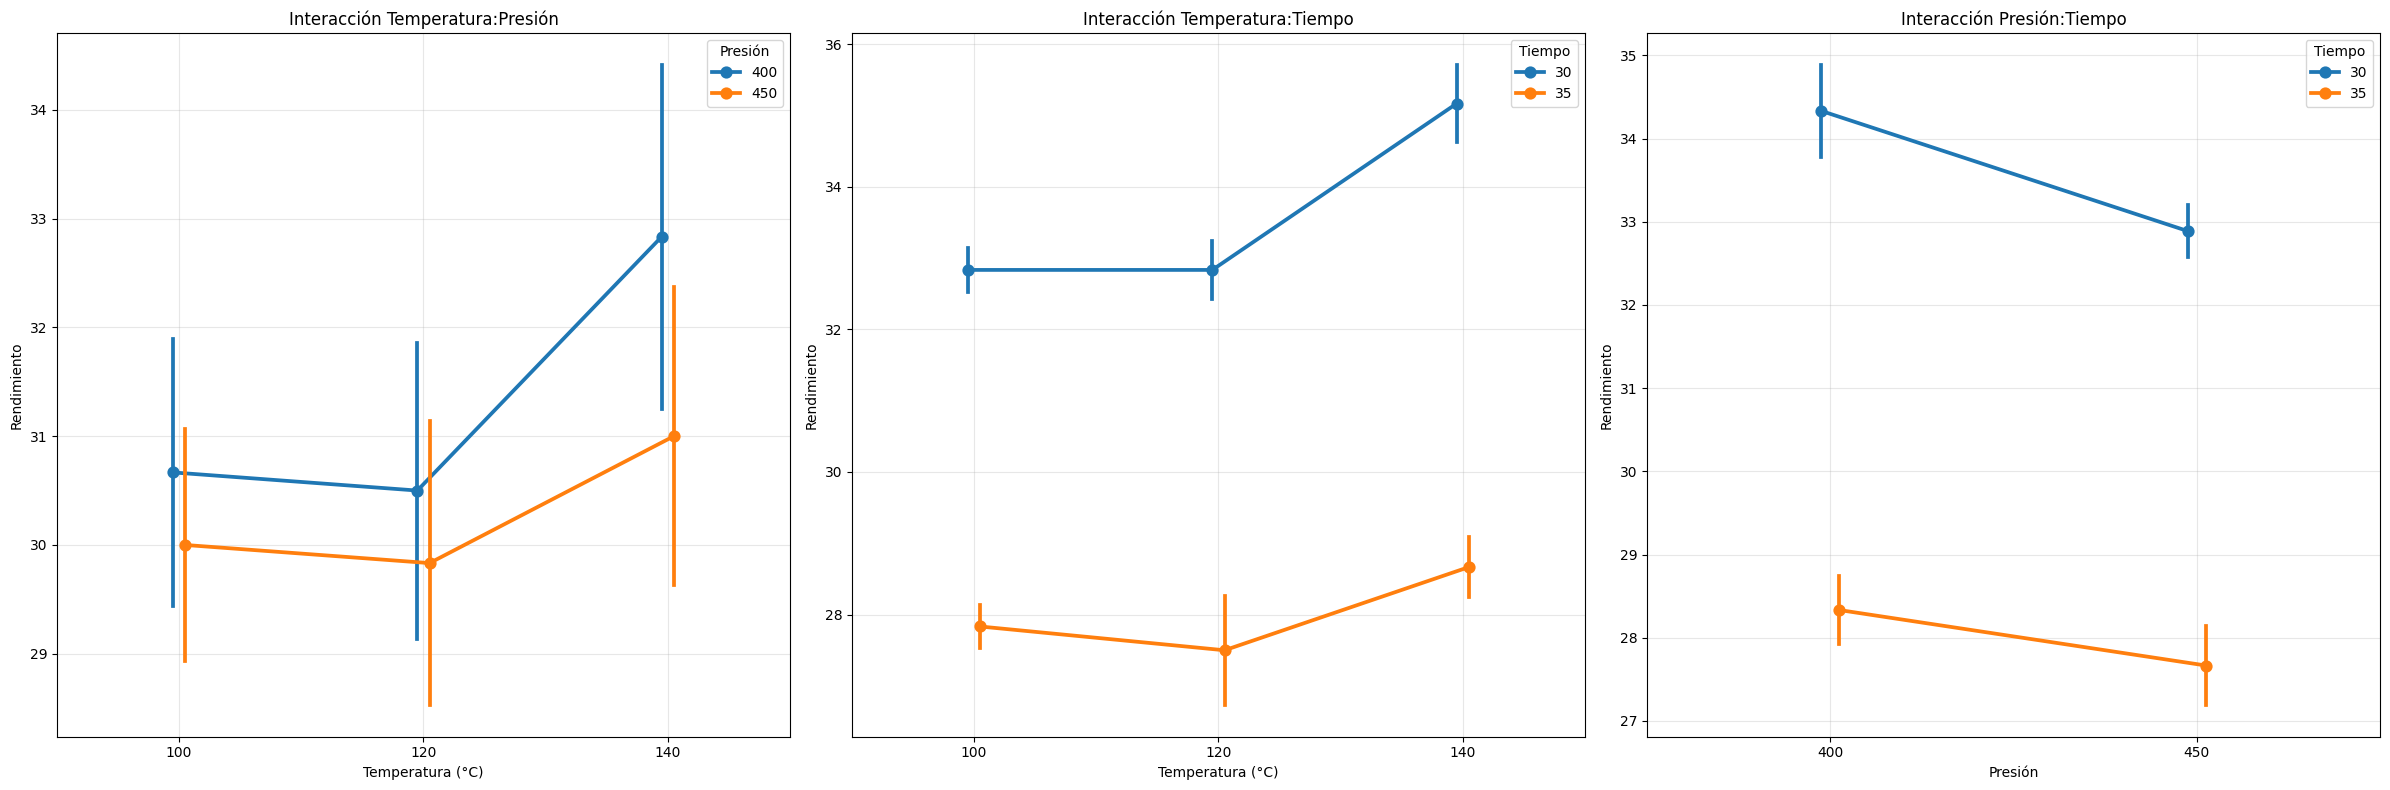

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming df is already loaded and contains 'Temperatura', 'Presion', 'Tiempo', and 'Rendimiento'

# Convert factor columns to strings for plotting if they are not already
df['Temperatura'] = df['Temperatura'].astype(str)
df['Presion'] = df['Presion'].astype(str)
df['Tiempo'] = df['Tiempo'].astype(str)

# Create interaction plots for two-way interactions using seaborn
plt.figure(figsize=(24, 8)) # Increased figure size

# Temperatura:Presion Interaction Plot
plt.subplot(1, 3, 1)
sns.pointplot(data=df, x='Temperatura', y='Rendimiento', hue='Presion', dodge=True, errorbar='se')
plt.title('Interacción Temperatura:Presión')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Rendimiento')
plt.legend(title='Presión')
plt.grid(True, alpha=0.3)

# Temperatura:Tiempo Interaction Plot
plt.subplot(1, 3, 2)
sns.pointplot(data=df, x='Temperatura', y='Rendimiento', hue='Tiempo', dodge=True, errorbar='se')
plt.title('Interacción Temperatura:Tiempo')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Rendimiento')
plt.legend(title='Tiempo')
plt.grid(True, alpha=0.3)

# Presion:Tiempo Interaction Plot
plt.subplot(1, 3, 3)
sns.pointplot(data=df, x='Presion', y='Rendimiento', hue='Tiempo', dodge=True, errorbar='se')
plt.title('Interacción Presión:Tiempo')
plt.xlabel('Presión')
plt.ylabel('Rendimiento')
plt.legend(title='Tiempo')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

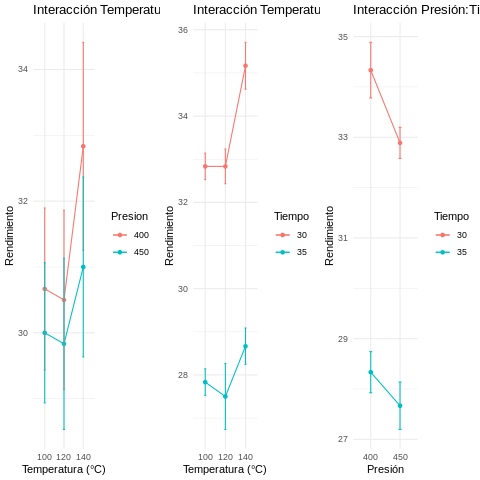

In [43]:
%%R
# Install and load ggplot2 if not already installed
if (!require("ggplot2")) install.packages("ggplot2")
library(ggplot2)

# Create interaction plots for two-way interactions using ggplot2

# Temperatura:Presion Interaction Plot
plot_temp_presion <- ggplot(data_r, aes(x = Temperatura, y = Rendimiento, color = Presion, group = Presion)) +
  stat_summary(fun = mean, geom = "point") +
  stat_summary(fun = mean, geom = "line") +
  stat_summary(fun.data = mean_se, geom = "errorbar", width = 0.1) + # Add standard error bars
  labs(title = "Interacción Temperatura:Presión", x = "Temperatura (°C)", y = "Rendimiento") +
  theme_minimal()

# Temperatura:Tiempo Interaction Plot
plot_temp_tiempo <- ggplot(data_r, aes(x = Temperatura, y = Rendimiento, color = Tiempo, group = Tiempo)) +
  stat_summary(fun = mean, geom = "point") +
  stat_summary(fun = mean, geom = "line") +
    stat_summary(fun.data = mean_se, geom = "errorbar", width = 0.1) + # Add standard error bars
  labs(title = "Interacción Temperatura:Tiempo", x = "Temperatura (°C)", y = "Rendimiento") +
  theme_minimal()

# Presion:Tiempo Interaction Plot
plot_presion_tiempo <- ggplot(data_r, aes(x = Presion, y = Rendimiento, color = Tiempo, group = Tiempo)) +
  stat_summary(fun = mean, geom = "point") +
  stat_summary(fun = mean, geom = "line") +
    stat_summary(fun.data = mean_se, geom = "errorbar", width = 0.1) + # Add standard error bars
  labs(title = "Interacción Presión:Tiempo", x = "Presión", y = "Rendimiento") +
  theme_minimal()

# Arrange and print the plots with increased size
# Install and load gridExtra if not already installed
if (!require("gridExtra")) install.packages("gridExtra")
library(gridExtra)

# Adjust the layout size for larger plots
grid.arrange(plot_temp_presion, plot_temp_tiempo, plot_presion_tiempo, ncol = 3,
             widths = c(1, 1, 1), heights = c(1)) # Adjust heights/widths as needed